# GA-BO — Part 2: Experiments, Ablation & Analysis

> **Run Part 1 first** to define all classes and utility functions.
> This notebook loads those definitions via `%run GA_BO_Part1.ipynb`.

All packages installed.
Setup complete.
Registered 8 benchmark functions.
  Branin                dim=2  f*=0.3979
  Rosenbrock-4D         dim=4  f*=0.0000
  Ackley-5D             dim=5  f*=0.0000
  Rastrigin-5D          dim=5  f*=0.0000
  Levy-6D               dim=6  f*=0.0000
  Hartmann-6D           dim=6  f*=-3.3224
  Ackley-10D            dim=10  f*=0.0000
  Rastrigin-10D         dim=10  f*=0.0000
GP smoke-test: mu[:5] = [42.782 45.718 54.139 42.714 22.983]
LML = 63.823


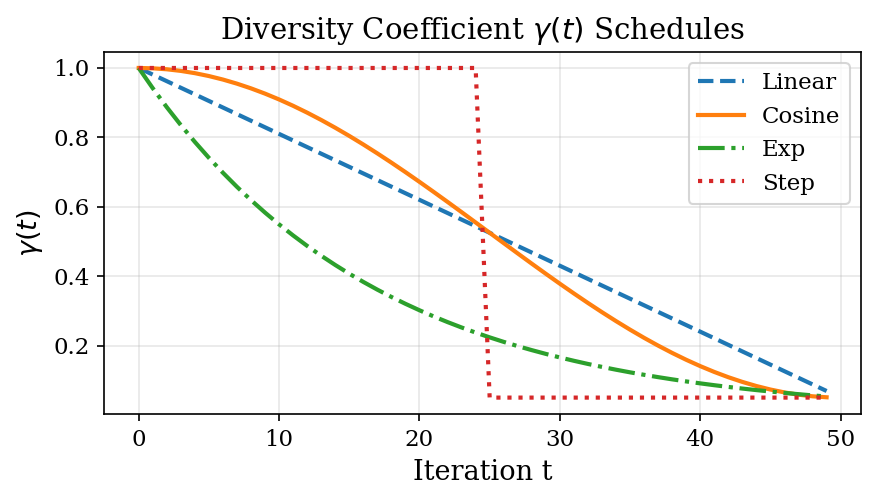

Figure saved.
GA and DE optimisers defined.
GA-BO framework defined.
Baseline methods defined.


In [1]:
%run GA_BO_Part1

## 7. Experiment Runner

In [2]:
def run_single(
    method_cls,
    method_kwargs: dict,
    fn: TestFunction,
    seed: int,
    n_init: int = 5,
    n_iter: int = 50,
) -> BOResult:
    """Run one method on one function with one seed."""
    kwargs = dict(bounds=fn.bounds, n_init=n_init, n_iter=n_iter,
                  seed=seed, **method_kwargs)
    algo   = method_cls(**kwargs)
    return algo.run(fn.func, func_name=fn.name)


def run_experiment(
    methods: Dict[str, Tuple],
    functions: Dict[str, TestFunction],
    n_seeds: int = 20,
    n_init: int  = 5,
    n_iter: int  = 50,
    n_jobs: int  = 1,   # kept for API compat, sequential loop used
    save_path: Optional[str] = None,
) -> Dict[str, Dict[str, List[BOResult]]]:
    """
    Full factorial experiment: methods x functions x seeds.
    Uses a simple sequential loop (reliable across all platforms).
    """
    tasks = [
        (mname, mcls, mkwargs, fname, fn, seed)
        for mname, (mcls, mkwargs) in methods.items()
        for fname, fn in functions.items()
        for seed in range(n_seeds)
    ]
    print(f'Total tasks: {len(tasks)}  ' +
          f'({len(methods)} methods x {len(functions)} functions x {n_seeds} seeds)')

    results = {m: {f: [] for f in functions} for m in methods}

    for mname, mcls, mkwargs, fname, fn, seed in tqdm(tasks, desc='Running'):
        r = run_single(mcls, mkwargs, fn, seed, n_init, n_iter)
        r.method = mname
        results[mname][fname].append(r)

    if save_path:
        serialisable = {
            m: {f: [r.best_values for r in rs]
                for f, rs in fd.items()}
            for m, fd in results.items()
        }
        with open(save_path, 'w', encoding='utf-8') as fp:
            json.dump(serialisable, fp)
        print(f'Results saved -> {save_path}')

    return results


print('Experiment runner ready.')

Experiment runner ready.


## 8. Run Main Benchmark

In [3]:
METHODS = {
    'GA-BO (DA-EI)': (
        GABO,
        dict(acq_type='da_ei', optimizer_type='ga',
             gamma_init=1.0, gamma_final=0.05, gamma_decay='cosine')
    ),
    'GA-BO (EI)': (
        GABO,
        dict(acq_type='ei', optimizer_type='ga')
    ),
    'DE-BO (DA-EI)': (
        GABO,
        dict(acq_type='da_ei', optimizer_type='de',
             gamma_init=1.0, gamma_final=0.05, gamma_decay='cosine')
    ),
    'Standard-BO': (
        StandardBO,
        dict()
    ),
    'Random': (
        RandomSearch,
        dict()
    ),
}

# ── Run (use subset for fast preview) ──────────────────────────────────────
N_SEEDS = 20
N_INIT  = 5
N_ITER  = 50

RESULTS = run_experiment(
    METHODS,
    BENCHMARK_FUNCTIONS,
    n_seeds=N_SEEDS,
    n_init=N_INIT,
    n_iter=N_ITER,
    n_jobs=1,
    save_path=f'{RESULTS_DIR}/main_results.json'
)
print('\nDone.')

Total tasks: 800  (5 methods x 8 functions x 20 seeds)


Running:   0%|          | 0/800 [00:00<?, ?it/s]

Results saved -> results/main_results.json

Done.


## 9. Regret Computation & Summary Table

In [4]:
def compute_regret(
    results: Dict,
    functions: Dict[str, TestFunction]
) -> pd.DataFrame:
    """
    Compute Simple Regret = best_found - f*  at final iteration.
    Returns tidy DataFrame with mean ± std across seeds.
    """
    rows = []
    for mname, func_dict in results.items():
        for fname, run_list in func_dict.items():
            f_opt = functions[fname].global_optimum
            final_regrets = [r.best_values[-1] - f_opt for r in run_list]
            rows.append(dict(
                Method=mname, Function=fname,
                Mean_Regret=np.mean(final_regrets),
                Std_Regret=np.std(final_regrets),
                Median_Regret=np.median(final_regrets),
                IQR=np.percentile(final_regrets, 75) - np.percentile(final_regrets, 25)
            ))
    return pd.DataFrame(rows)


regret_df = compute_regret(RESULTS, BENCHMARK_FUNCTIONS)

# ── Pivot table (mean ± std) ────────────────────────────────────────────────
pivot_mean = regret_df.pivot(index='Method', columns='Function', values='Mean_Regret')
pivot_std  = regret_df.pivot(index='Method', columns='Function', values='Std_Regret')

# Format as mean±std strings
def fmt(m, s): return f'{m:.4f} ± {s:.4f}'
pivot_str = pivot_mean.copy().astype(str)
for col in pivot_mean.columns:
    pivot_str[col] = [fmt(m, s) for m, s in zip(pivot_mean[col], pivot_std[col])]

print('\n=== Simple Regret (mean ± std, lower is better) ===\n')
print(pivot_str.to_string())

# Rank each method per function (lower regret = better rank)
ranks = pivot_mean.rank(axis=0, ascending=True)
ranks['Avg_Rank'] = ranks.mean(axis=1)
print('\n=== Average Rank (lower is better) ===')
print(ranks['Avg_Rank'].sort_values())

# Save table
pivot_str.to_csv(f'{RESULTS_DIR}/regret_table.csv')
print('\nTable saved.')


=== Simple Regret (mean ± std, lower is better) ===

Function            Ackley-10D        Ackley-5D           Branin      Hartmann-6D           Levy-6D       Rastrigin-10D       Rastrigin-5D      Rosenbrock-4D
Method                                                                                                                                                       
DE-BO (DA-EI)  6.7543 ± 0.6097  5.0144 ± 0.6232  0.0669 ± 0.1288  1.1221 ± 0.7825   4.2190 ± 1.6255  106.7983 ± 12.0900   33.1942 ± 9.4003    9.9776 ± 4.5572
GA-BO (DA-EI)  2.5634 ± 0.4084  1.4200 ± 0.6335  0.0027 ± 0.0028  0.1584 ± 0.1081   0.9781 ± 0.5000   84.0529 ± 21.0540  23.3478 ± 12.9871    3.5188 ± 1.6532
GA-BO (EI)     2.9209 ± 0.6859  1.9633 ± 0.9319  0.0014 ± 0.0011  0.1191 ± 0.1191   5.4206 ± 5.3864   84.3424 ± 19.0298   24.3882 ± 9.7628    3.9422 ± 1.7337
Random         7.7648 ± 0.6281  5.9823 ± 0.8437  1.0516 ± 1.0104  1.4868 ± 0.4355  11.9770 ± 3.5115  114.9665 ± 11.9238   46.5890 ± 9.8818  64.2418 ± 68.929

## 10. Convergence Plots

Saved convergence.pdf


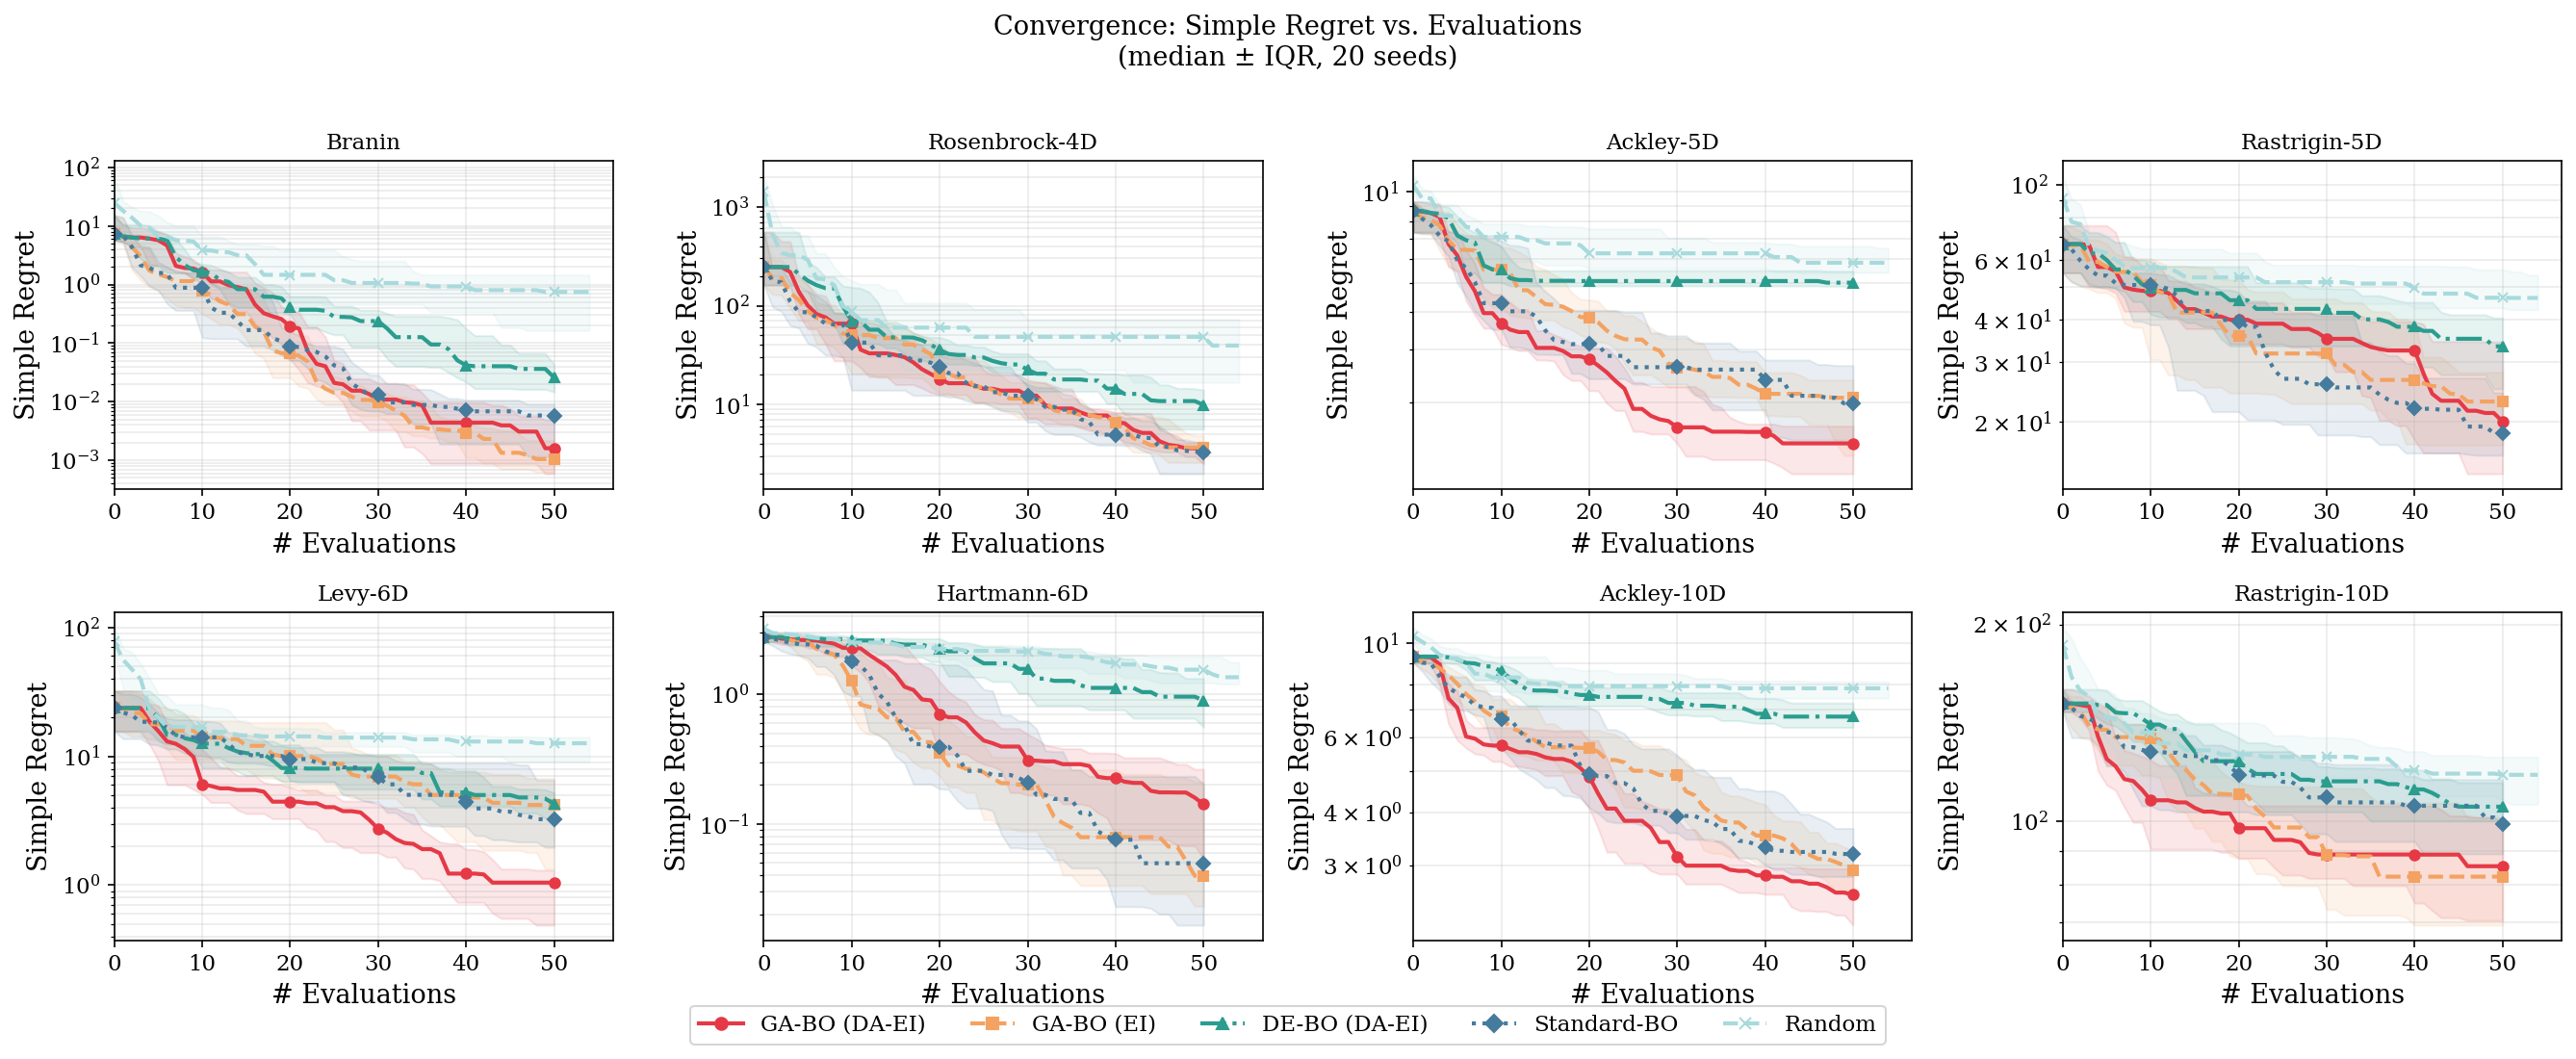

In [9]:
METHOD_STYLES = {
    'GA-BO (DA-EI)': dict(color='#E63946', ls='-',  marker='o', label='GA-BO (DA-EI)'),
    'GA-BO (EI)':    dict(color='#F4A261', ls='--', marker='s', label='GA-BO (EI)'),
    'DE-BO (DA-EI)': dict(color='#2A9D8F', ls='-.',marker='^', label='DE-BO (DA-EI)'),
    'Standard-BO':   dict(color='#457B9D', ls=':',  marker='D', label='Standard-BO'),
    'Random':        dict(color='#A8DADC', ls='--', marker='x', label='Random'),
}


def plot_convergence(
    results: Dict,
    functions: Dict[str, TestFunction],
    figsize_per_plot=(4.5, 3.5),
    n_cols=4,
    save=True
):
    fn_names = list(functions.keys())
    n_fns    = len(fn_names)
    n_rows   = (n_fns + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_plot[0]*n_cols, figsize_per_plot[1]*n_rows),
        squeeze=False
    )
    axes = axes.flatten()

    for ax_idx, fname in enumerate(fn_names):
        ax  = axes[ax_idx]
        f_opt = functions[fname].global_optimum

        for mname, st in METHOD_STYLES.items():
            if mname not in results or fname not in results[mname]:
                continue
            run_list = results[mname][fname]
            # Regret curves
            curves = np.array([np.array(r.best_values) - f_opt
                               for r in run_list])
            med  = np.median(curves, axis=0)
            q25  = np.percentile(curves, 25, axis=0)
            q75  = np.percentile(curves, 75, axis=0)
            xs   = np.arange(len(med))
            ax.semilogy(xs, np.maximum(med, 1e-8), **{k: v for k, v in st.items()
                                                       if k != 'marker'},
                        marker=st['marker'], markevery=10, markersize=5)
            ax.fill_between(xs, np.maximum(q25, 1e-8),
                            np.maximum(q75, 1e-8),
                            alpha=0.12, color=st['color'])

        ax.set_title(fname, fontsize=11)
        ax.set_xlabel('# Evaluations')
        ax.set_ylabel('Simple Regret')
        ax.grid(True, which='both', alpha=0.25)
        ax.set_xlim(left=0)

    # Hide unused
    for i in range(n_fns, len(axes)):
        axes[i].set_visible(False)

    # Shared legend
    handles = [
        plt.Line2D(
            [0], [0],
            **{k: v for k, v in st.items() if k not in ['marker', 'label']},
            marker=st['marker'],
            markersize=6,
            label=st['label']
        )
        for mname, st in METHOD_STYLES.items() if mname in results
    ]
    fig.legend(handles=handles, loc='lower center',
               ncol=len(handles), bbox_to_anchor=(0.5, -0.02),
               frameon=True, fontsize=11)
    plt.suptitle('Convergence: Simple Regret vs. Evaluations\n(median ± IQR, 20 seeds)',
                 y=1.01, fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig(f'{FIGURES_DIR}/convergence.pdf', bbox_inches='tight')
        print('Saved convergence.pdf')
    plt.show()


plot_convergence(RESULTS, BENCHMARK_FUNCTIONS)

## 11. Statistical Significance Tests

In [10]:
from scipy.stats import wilcoxon, friedmanchisquare


def wilcoxon_pairwise(
    results: Dict,
    functions: Dict[str, TestFunction],
    proposed: str = 'GA-BO (DA-EI)',
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Pairwise Wilcoxon signed-rank test:
      H0: proposed and baseline have equal final regret.
    Returns DataFrame of p-values and W/L/T counts.
    """
    fn_names  = list(functions.keys())
    baselines = [m for m in results if m != proposed]
    rows = []

    for baseline in baselines:
        for fname in fn_names:
            f_opt   = functions[fname].global_optimum
            r_prop  = [r.best_values[-1] - f_opt
                       for r in results[proposed][fname]]
            r_base  = [r.best_values[-1] - f_opt
                       for r in results[baseline][fname]]
            # Align lengths
            n = min(len(r_prop), len(r_base))
            try:
                stat, p = wilcoxon(r_prop[:n], r_base[:n], alternative='less')
            except Exception:
                stat, p = np.nan, np.nan
            # Win/Lose/Tie
            diff = np.array(r_prop[:n]) - np.array(r_base[:n])
            wlt = ('W' if np.median(diff) < 0 else
                   'T' if np.median(diff) == 0 else 'L')
            rows.append(dict(
                Baseline=baseline, Function=fname,
                p_value=round(p, 4),
                Significant=('Yes' if p < alpha else 'No'),
                WLT=wlt
            ))

    df = pd.DataFrame(rows)

    # Summary per baseline
    print(f'\n=== Wilcoxon Test: {proposed} vs. Baselines (α={alpha}) ===')
    _pd_ver = tuple(int(x) for x in pd.__version__.split('.')[:2])
    _apply_kwargs = {'include_groups': False} if _pd_ver >= (2, 2) else {}
    summary = df.groupby('Baseline').apply(
        lambda g: pd.Series({
            'Wins': (g['WLT']=='W').sum(),
            'Losses': (g['WLT']=='L').sum(),
            'Ties': (g['WLT']=='T').sum(),
            'Sig (p<alpha)': g['Significant'].eq('Yes').sum()
        }), **_apply_kwargs
    )
    if isinstance(summary.index, pd.MultiIndex):
        summary = summary.droplevel(1)
    print(summary.to_string())
    df.to_csv(f'{RESULTS_DIR}/wilcoxon_tests.csv', index=False)
    return df


stat_df = wilcoxon_pairwise(RESULTS, BENCHMARK_FUNCTIONS)


def friedman_test(
    results: Dict,
    functions: Dict[str, TestFunction]
):
    """
    Friedman test across all methods for each function.
    If significant, compute Nemenyi critical difference diagram data.
    """
    method_names = list(results.keys())
    print('\n=== Friedman Test ===')
    for fname in functions:
        f_opt = functions[fname].global_optimum
        data = [
            [r.best_values[-1] - f_opt for r in results[m][fname]]
            for m in method_names
        ]
        min_len = min(len(d) for d in data)
        data    = [d[:min_len] for d in data]
        try:
            stat, p = friedmanchisquare(*data)
            print(f'  {fname:20s}  χ²={stat:.3f}  p={p:.4f}  '
                  f'{"**significant**" if p < 0.05 else ""}')
        except Exception as e:
            print(f'  {fname}: {e}')


friedman_test(RESULTS, BENCHMARK_FUNCTIONS)


=== Wilcoxon Test: GA-BO (DA-EI) vs. Baselines (α=0.05) ===
               Wins  Losses  Ties  Sig (p<alpha)
Baseline                                        
DE-BO (DA-EI)     8       0     0              8
GA-BO (EI)        5       3     0              3
Random            8       0     0              8
Standard-BO       6       2     0              5

=== Friedman Test ===
  Branin                χ²=59.040  p=0.0000  **significant**
  Rosenbrock-4D         χ²=57.920  p=0.0000  **significant**
  Ackley-5D             χ²=64.040  p=0.0000  **significant**
  Rastrigin-5D          χ²=29.800  p=0.0000  **significant**
  Levy-6D               χ²=49.440  p=0.0000  **significant**
  Hartmann-6D           χ²=48.400  p=0.0000  **significant**
  Ackley-10D            χ²=67.720  p=0.0000  **significant**
  Rastrigin-10D         χ²=35.820  p=0.0000  **significant**


## 12. Ablation Study

In [12]:
# ── Ablation 1: Effect of γ decay schedule ─────────────────────────────────

ABLATION_FNS = {
    'Ackley-5D':   BENCHMARK_FUNCTIONS['Ackley-5D'],
    'Hartmann-6D': BENCHMARK_FUNCTIONS['Hartmann-6D'],
    'Rastrigin-10D': BENCHMARK_FUNCTIONS['Rastrigin-10D'],
}

ABLATION_SCHEDULES = {
    'GA-BO Cosine': (GABO, dict(acq_type='da_ei', gamma_decay='cosine')),
    'GA-BO Linear': (GABO, dict(acq_type='da_ei', gamma_decay='linear')),
    'GA-BO Exp':    (GABO, dict(acq_type='da_ei', gamma_decay='exp')),
    'GA-BO Step':   (GABO, dict(acq_type='da_ei', gamma_decay='step')),
    'GA-BO γ=0':    (GABO, dict(acq_type='da_ei', gamma_init=0.0, gamma_final=0.0)),
    'GA-BO γ=1':    (GABO, dict(acq_type='da_ei', gamma_init=1.0, gamma_final=1.0)),
}

abl_schedule_results = run_experiment(
    ABLATION_SCHEDULES, ABLATION_FNS,
    n_seeds=15, n_init=5, n_iter=50, n_jobs=1,
    save_path=f'{RESULTS_DIR}/ablation_schedule.json'
)

print('Ablation 1 done.')

Total tasks: 270  (6 methods x 3 functions x 15 seeds)


Running:   0%|          | 0/270 [00:00<?, ?it/s]

Results saved -> results/ablation_schedule.json
Ablation 1 done.


In [13]:
# ── Ablation 2: Warm-start vs. no warm-start ───────────────────────────────

class GABONoWarm(GABO):
    """GA-BO without warm-start (cold random init each iter)."""
    def run(self, objective, func_name='unknown', verbose=False):
        self.n_elite_warm = 0
        return super().run(objective, func_name, verbose)


ABLATION_WARM = {
    'GA-BO Warm': (GABO,       dict(acq_type='da_ei', n_elite_warm=5)),
    'GA-BO No-Warm': (GABONoWarm, dict(acq_type='da_ei', n_elite_warm=0)),
}

abl_warm_results = run_experiment(
    ABLATION_WARM, ABLATION_FNS,
    n_seeds=15, n_init=5, n_iter=50, n_jobs=1,
    save_path=f'{RESULTS_DIR}/ablation_warmstart.json'
)
print('Ablation 2 done.')

Total tasks: 90  (2 methods x 3 functions x 15 seeds)


Running:   0%|          | 0/90 [00:00<?, ?it/s]

Results saved -> results/ablation_warmstart.json
Ablation 2 done.


In [14]:
# ── Ablation 3: Population size impact ─────────────────────────────────────

ABLATION_POP = {
    'GA-BO Pop-50':  (GABO, dict(acq_type='da_ei', ga_pop_init=50,  ga_pop_final=10)),
    'GA-BO Pop-100': (GABO, dict(acq_type='da_ei', ga_pop_init=100, ga_pop_final=20)),
    'GA-BO Pop-200': (GABO, dict(acq_type='da_ei', ga_pop_init=200, ga_pop_final=40)),
    'GA-BO Fixed-50':(GABO, dict(acq_type='da_ei', ga_pop_init=50,  ga_pop_final=50)),
}

abl_pop_results = run_experiment(
    ABLATION_POP, ABLATION_FNS,
    n_seeds=15, n_init=5, n_iter=50, n_jobs=1,
    save_path=f'{RESULTS_DIR}/ablation_popsize.json'
)
print('Ablation 3 done.')

Total tasks: 180  (4 methods x 3 functions x 15 seeds)


Running:   0%|          | 0/180 [00:00<?, ?it/s]

Results saved -> results/ablation_popsize.json
Ablation 3 done.


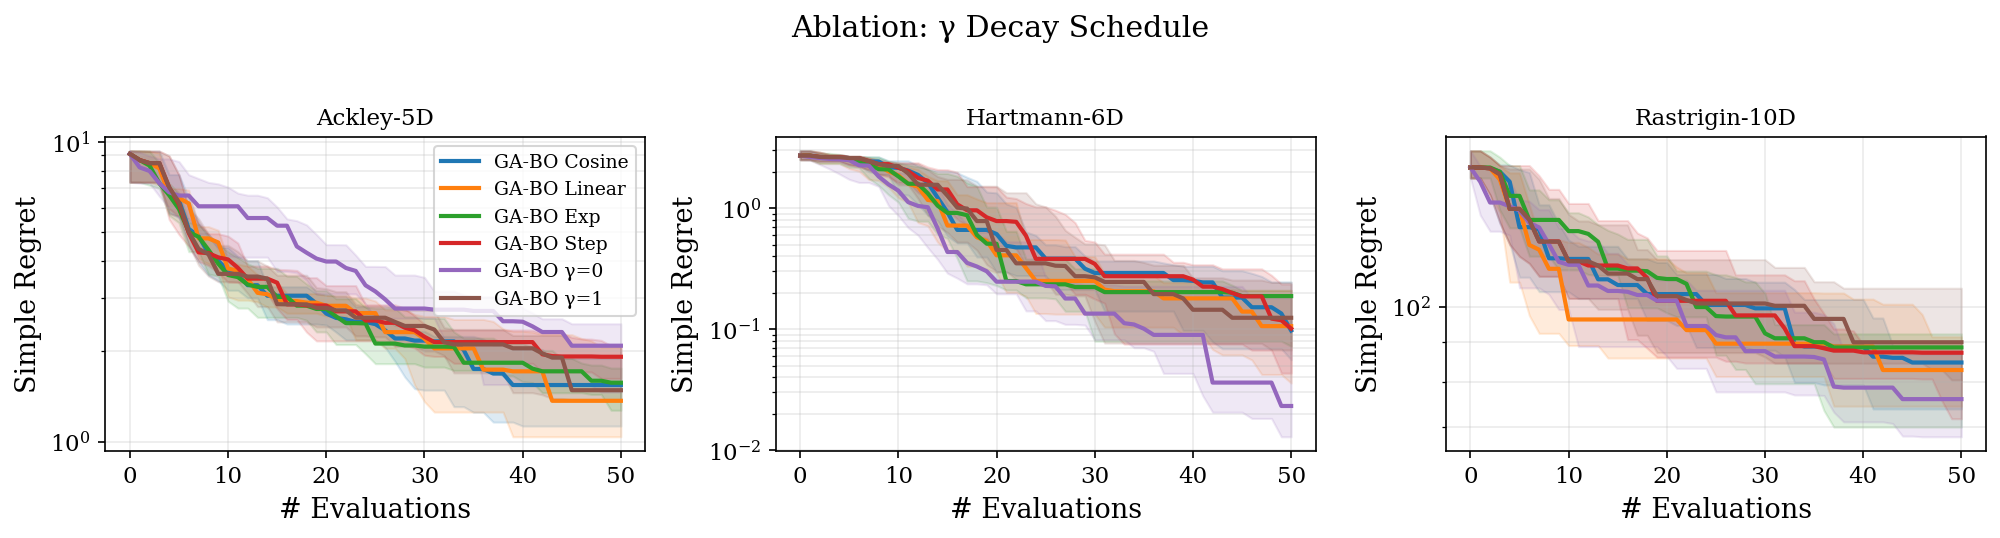

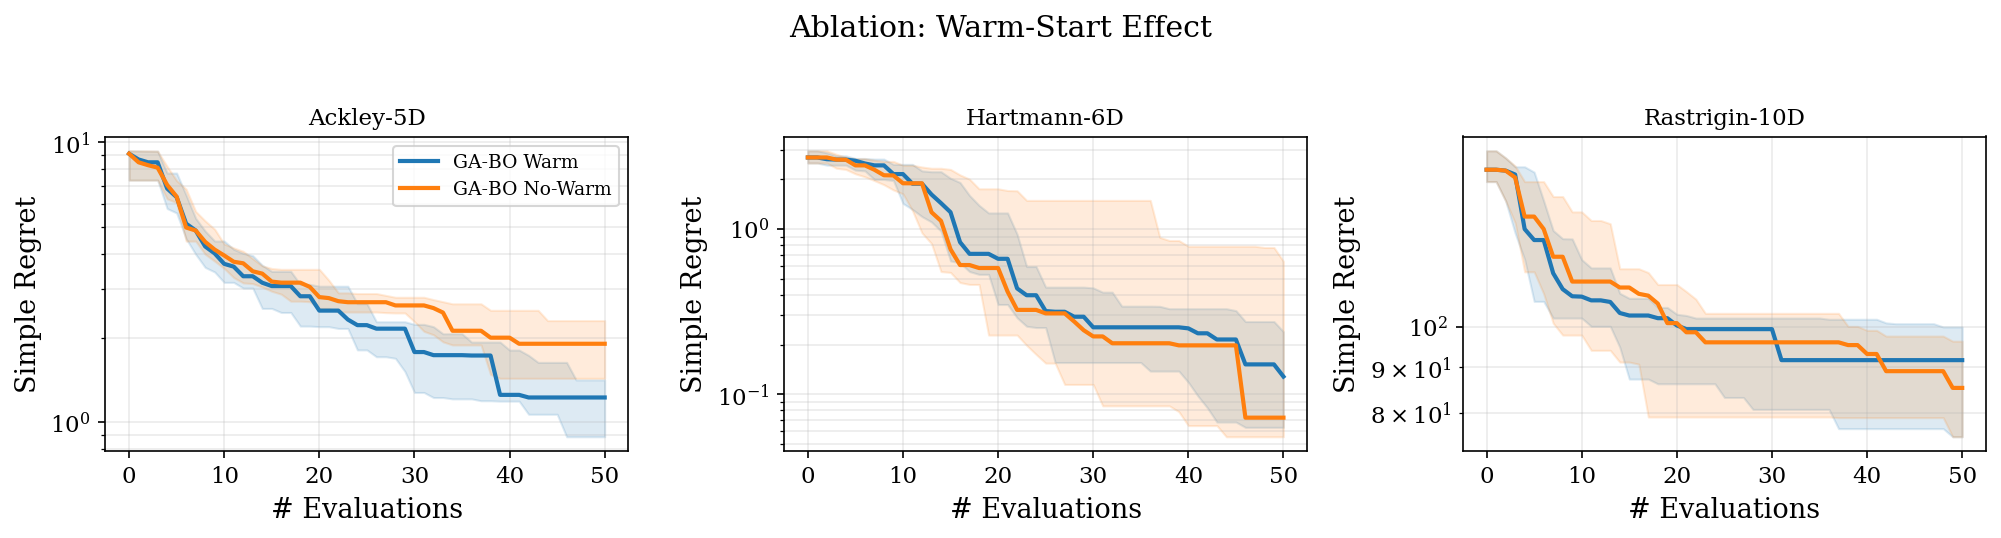

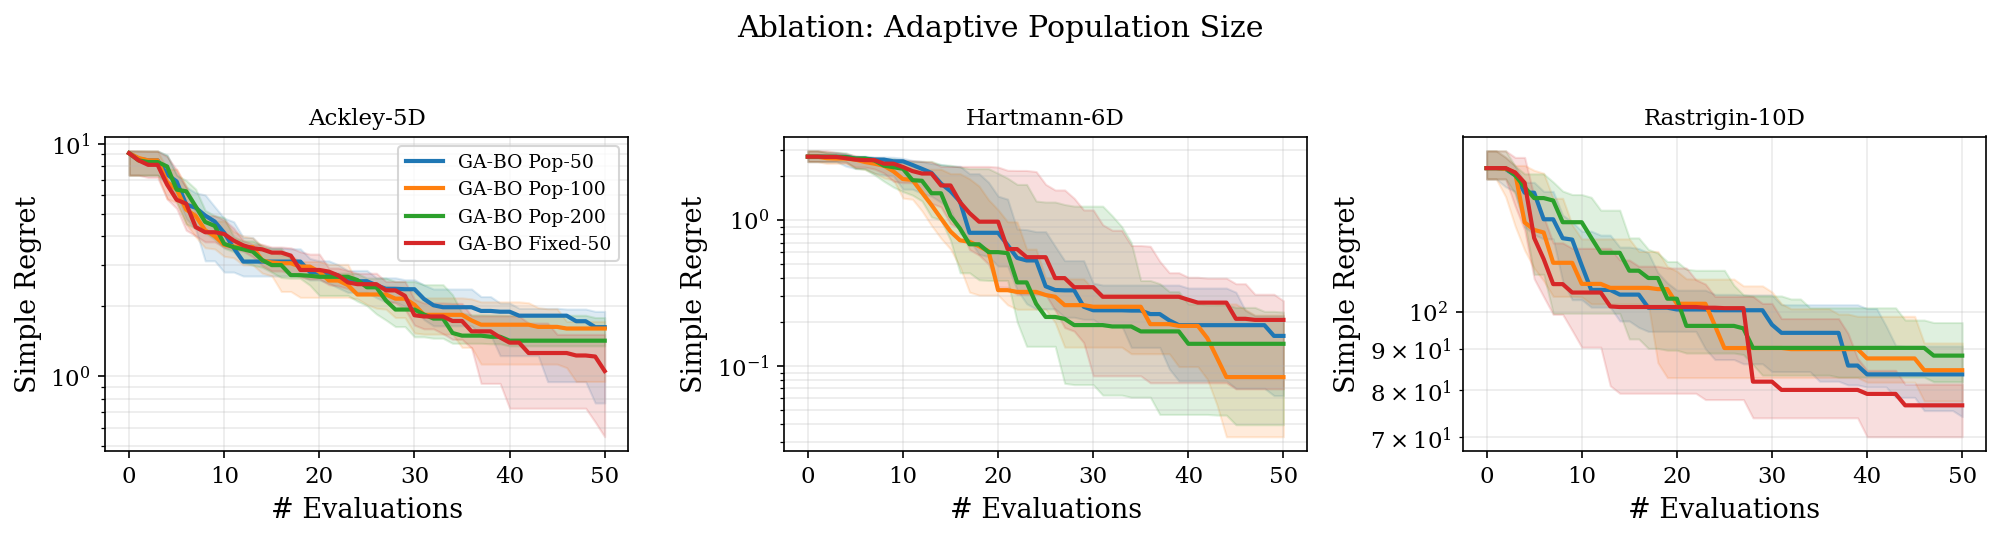

In [15]:
def plot_ablation(
    ablation_results: Dict,
    functions: Dict[str, TestFunction],
    title: str,
    filename: str
):
    fn_names  = list(functions.keys())
    colors    = sns.color_palette('tab10', len(ablation_results))
    n_cols    = len(fn_names)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.5*n_cols, 3.5),
                              squeeze=False)
    axes = axes.flatten()

    for ax, fname in zip(axes, fn_names):
        f_opt = functions[fname].global_optimum
        for mname, color in zip(ablation_results.keys(), colors):
            run_list = ablation_results[mname][fname]
            curves = np.array([np.array(r.best_values) - f_opt for r in run_list])
            med    = np.median(curves, axis=0)
            q25    = np.percentile(curves, 25, axis=0)
            q75    = np.percentile(curves, 75, axis=0)
            xs     = np.arange(len(med))
            ax.semilogy(xs, np.maximum(med, 1e-8), label=mname, color=color)
            ax.fill_between(xs, np.maximum(q25, 1e-8),
                            np.maximum(q75, 1e-8), alpha=0.15, color=color)
        ax.set_title(fname, fontsize=11)
        ax.set_xlabel('# Evaluations')
        ax.set_ylabel('Simple Regret')
        ax.grid(True, which='both', alpha=0.25)
    axes[0].legend(fontsize=9)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/{filename}', bbox_inches='tight')
    plt.show()


plot_ablation(abl_schedule_results, ABLATION_FNS,
              'Ablation: γ Decay Schedule', 'ablation_schedule.pdf')
plot_ablation(abl_warm_results, ABLATION_FNS,
              'Ablation: Warm-Start Effect', 'ablation_warmstart.pdf')
plot_ablation(abl_pop_results, ABLATION_FNS,
              'Ablation: Adaptive Population Size', 'ablation_popsize.pdf')

## 13. Diversity Analysis

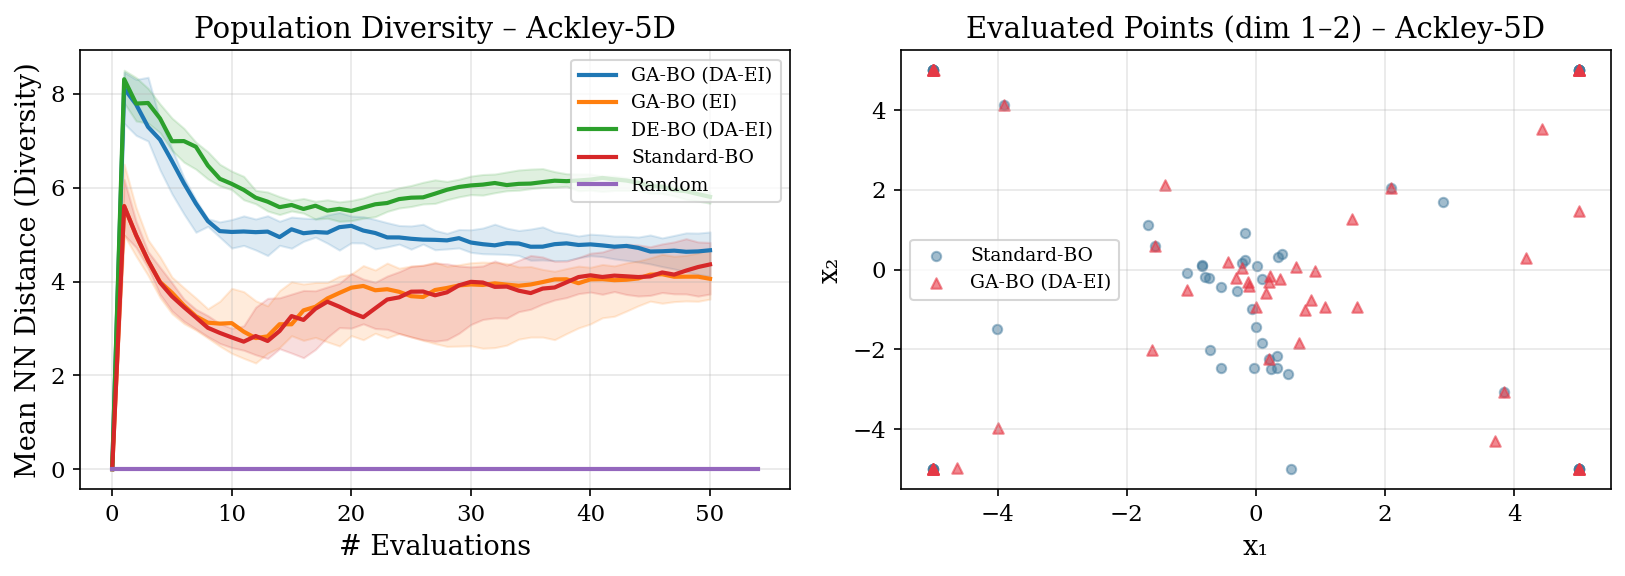

In [16]:
def plot_diversity_comparison(
    results: Dict,
    fname: str = 'Ackley-5D',
    methods_to_plot: Optional[List[str]] = None,
):
    """
    Plot mean nearest-neighbour distance (diversity) over iterations.
    High diversity → broader exploration.
    """
    if methods_to_plot is None:
        methods_to_plot = list(results.keys())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    colors = sns.color_palette('tab10', len(methods_to_plot))

    # Left: diversity over iterations
    for mname, color in zip(methods_to_plot, colors):
        run_list = results[mname][fname]
        curves = np.array([r.diversity_hist for r in run_list])
        med    = np.median(curves, axis=0)
        q25    = np.percentile(curves, 25, axis=0)
        q75    = np.percentile(curves, 75, axis=0)
        xs     = np.arange(len(med))
        axes[0].plot(xs, med, color=color, label=mname)
        axes[0].fill_between(xs, q25, q75, alpha=0.15, color=color)

    axes[0].set_xlabel('# Evaluations')
    axes[0].set_ylabel('Mean NN Distance (Diversity)')
    axes[0].set_title(f'Population Diversity – {fname}')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Right: scatter of evaluated points for GA-BO vs Standard-BO (2D projection)
    # Use first run, first 2 dims
    if ('GA-BO (DA-EI)' in results and fname in results['GA-BO (DA-EI)']
            and 'Standard-BO' in results and fname in results['Standard-BO']
            and results['Standard-BO'][fname]):
        r_ga = results['GA-BO (DA-EI)'][fname][0]
        r_bo = results['Standard-BO'][fname][0]
        axes[1].scatter(r_bo.x_history[:, 0], r_bo.x_history[:, 1],
                        c='#457B9D', alpha=0.5, s=20, label='Standard-BO', marker='o')
        axes[1].scatter(r_ga.x_history[:, 0], r_ga.x_history[:, 1],
                        c='#E63946', alpha=0.6, s=25, label='GA-BO (DA-EI)', marker='^')
        axes[1].set_xlabel('x₁')
        axes[1].set_ylabel('x₂')
        axes[1].set_title(f'Evaluated Points (dim 1–2) – {fname}')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/diversity_analysis.pdf', bbox_inches='tight')
    plt.show()


plot_diversity_comparison(RESULTS, fname='Ackley-5D')

## 14. Scalability Analysis (High-Dimensional)

Total tasks: 225  (3 methods x 5 functions x 15 seeds)


Running:   0%|          | 0/225 [00:00<?, ?it/s]

Results saved -> results/dim_study.json


TypeError: matplotlib.lines.Line2D() got multiple values for keyword argument 'label'

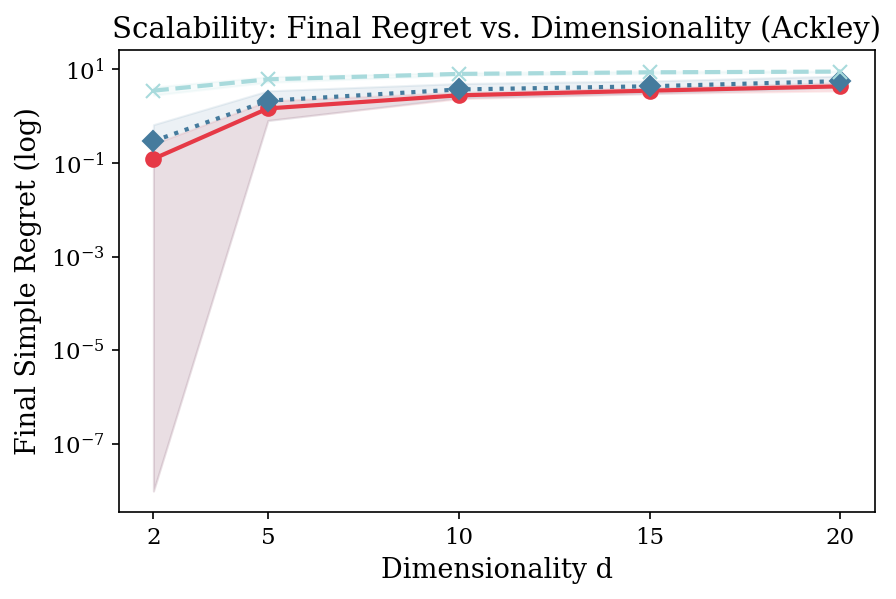

In [ ]:
DIM_STUDY = {}
for d in [2, 5, 10, 15, 20]:
    DIM_STUDY[f'Ackley-{d}D'] = TestFunction(
        name=f'Ackley-{d}D', func=ackley,
        bounds=np.array([[-5, 5]]*d),
        global_optimum=0.0, dim=d,
        optimal_x=np.zeros(d)
    )

DIM_METHODS = {
    'GA-BO (DA-EI)': METHODS['GA-BO (DA-EI)'],
    'Standard-BO':   METHODS['Standard-BO'],
    'Random':        METHODS['Random'],
}

dim_results = run_experiment(
    DIM_METHODS, DIM_STUDY,
    n_seeds=15, n_init=5, n_iter=50, n_jobs=1,
    save_path=f'{RESULTS_DIR}/dim_study.json'
)


# ── Plot: final regret vs dimensionality ───────────────────────────────────
dims    = [2, 5, 10, 15, 20]
fig, ax = plt.subplots(figsize=(6.5, 4))

for mname, st in METHOD_STYLES.items():
    if mname not in dim_results:
        continue
    means, stds = [], []
    for d in dims:
        fname = f'Ackley-{d}D'
        f_opt = DIM_STUDY[fname].global_optimum
        regrets = [r.best_values[-1] - f_opt
                   for r in dim_results[mname][fname]]
        means.append(np.mean(regrets))
        stds.append(np.std(regrets))
    means, stds = np.array(means), np.array(stds)
    ax.semilogy(dims, means, **{k: v for k, v in st.items() if k != 'marker'},
                marker=st['marker'], markersize=7)
    ax.fill_between(dims, np.maximum(means-stds, 1e-8),
                    means+stds, alpha=0.1, color=st['color'])

ax.set_xlabel('Dimensionality d')
ax.set_ylabel('Final Simple Regret (log)')
ax.set_title('Scalability: Final Regret vs. Dimensionality (Ackley)')
ax.set_xticks(dims)
handles = [
    plt.Line2D(
        [0], [0],
        **{k: v for k, v in st.items() if k not in ['marker', 'label']},
        marker=st['marker'],
        label=st['label']
    )
    for mname, st in METHOD_STYLES.items() if mname in dim_results
]
ax.legend(handles=handles, fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/scalability.pdf', bbox_inches='tight')
plt.show()

## 15. Real-World: ML Hyperparameter Optimisation

In [18]:
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# ── Pre-load datasets ONCE (not inside objective functions) ───────────────
_BC_DATA = load_breast_cancer()
_WINE_DATA = load_wine()

# ── Task 1: Random Forest on Breast Cancer ─────────────────────────────────
def rf_objective(x):
    """
    x = [n_estimators (int 10–300), max_depth (int 2–20),
         min_samples_split (int 2–20), max_features (float 0.1–1.0)]
    Returns: 1 - CV accuracy  (minimise)
    """
    data = _BC_DATA
    clf  = RandomForestClassifier(
        n_estimators=int(np.clip(x[0], 10, 300)),
        max_depth=int(np.clip(x[1], 2, 20)),
        min_samples_split=int(np.clip(x[2], 2, 20)),
        max_features=np.clip(x[3], 0.1, 1.0),
        random_state=0, n_jobs=1
    )
    score = cross_val_score(clf, data.data, data.target,
                            cv=5, scoring='accuracy').mean()
    return 1 - score   # minimise → maximise accuracy


RF_BOUNDS = np.array([
    [10,  300],   # n_estimators
    [2,   20],    # max_depth
    [2,   20],    # min_samples_split
    [0.1, 1.0],   # max_features
])

rf_fn = TestFunction(
    name='RF-BreastCancer', func=rf_objective,
    bounds=RF_BOUNDS, global_optimum=0.0, dim=4
)

# ── Task 2: SVM on Wine ────────────────────────────────────────────────────
def svm_objective(x):
    """
    x = [log10(C) in [-3,3], log10(gamma) in [-5,2]]
    """
    data  = _WINE_DATA
    C     = 10**x[0]
    gamma = 10**x[1]
    clf   = SVC(C=C, gamma=gamma, kernel='rbf', random_state=0)
    score = cross_val_score(clf, data.data, data.target,
                            cv=5, scoring='accuracy').mean()
    return 1 - score


SVM_BOUNDS = np.array([[-3, 3], [-5, 2]])  # log10 scale
svm_fn = TestFunction(
    name='SVM-Wine', func=svm_objective,
    bounds=SVM_BOUNDS, global_optimum=0.0, dim=2
)

# ── Task 3: GBM on Breast Cancer ──────────────────────────────────────────
def gbm_objective(x):
    """
    x = [n_estimators (50–500), learning_rate (0.01–0.5),
         max_depth (2–10), subsample (0.5–1.0)]
    """
    data = _BC_DATA
    clf  = GradientBoostingClassifier(
        n_estimators=int(np.clip(x[0], 50, 500)),
        learning_rate=np.clip(x[1], 0.01, 0.5),
        max_depth=int(np.clip(x[2], 2, 10)),
        subsample=np.clip(x[3], 0.5, 1.0),
        random_state=0
    )
    score = cross_val_score(clf, data.data, data.target,
                            cv=5, scoring='accuracy').mean()
    return 1 - score

GBM_BOUNDS = np.array([
    [50,  500],
    [0.01, 0.5],
    [2,   10],
    [0.5, 1.0],
])
gbm_fn = TestFunction(
    name='GBM-BreastCancer', func=gbm_objective,
    bounds=GBM_BOUNDS, global_optimum=0.0, dim=4
)

HPO_FUNCTIONS = {
    'RF-BreastCancer': rf_fn,
    'SVM-Wine':        svm_fn,
    'GBM-BreastCancer':gbm_fn,
}

print('HPO tasks defined.')

HPO tasks defined.


Total tasks: 150  (5 methods x 3 functions x 10 seeds)


Running:   0%|          | 0/150 [00:00<?, ?it/s]

Results saved -> results/hpo_results.json

=== HPO — Mean CV Accuracy (↑ better) ===
Task           GBM-BreastCancer  RF-BreastCancer  SVM-Wine
Method                                                    
DE-BO (DA-EI)            0.9745           0.9652    0.9332
GA-BO (DA-EI)            0.9756           0.9647    0.9332
GA-BO (EI)               0.9763           0.9645    0.9332
Random                   0.9737           0.9649    0.8708
Standard-BO              0.9752           0.9651    0.9332
Saved convergence.pdf


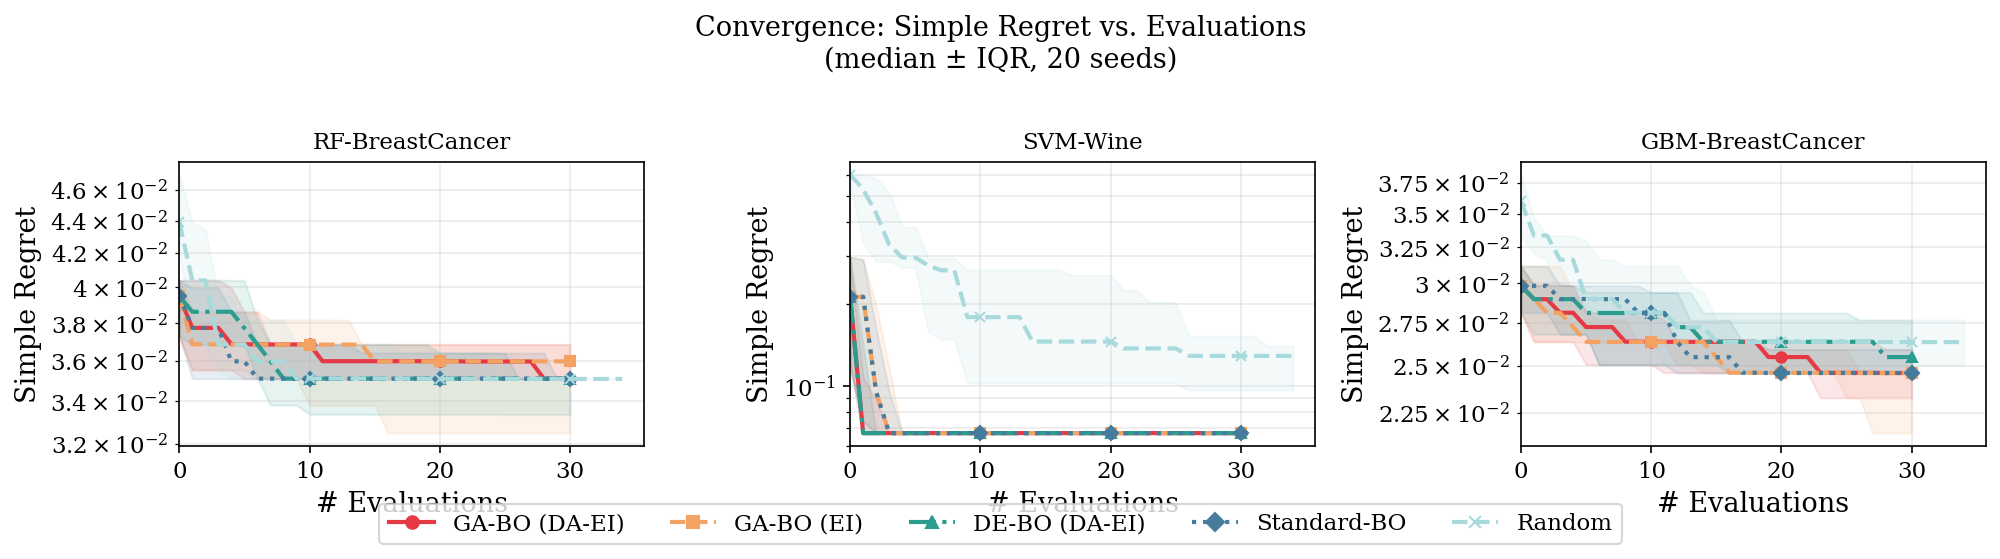

In [19]:
HPO_RESULTS = run_experiment(
    METHODS, HPO_FUNCTIONS,
    n_seeds=10, n_init=5, n_iter=30,
    n_jobs=1,
    save_path=f'{RESULTS_DIR}/hpo_results.json'
)

# ── Table: best accuracy achieved ─────────────────────────────────────────
hpo_rows = []
for mname, fd in HPO_RESULTS.items():
    for fname, run_list in fd.items():
        accs = [1 - r.best_values[-1] for r in run_list]
        hpo_rows.append(dict(
            Method=mname, Task=fname,
            Best_Acc=np.max(accs),
            Mean_Acc=np.mean(accs),
            Std_Acc=np.std(accs)
        ))

hpo_df = pd.DataFrame(hpo_rows)
hpo_pivot = hpo_df.pivot(index='Method', columns='Task', values='Mean_Acc')
print('\n=== HPO — Mean CV Accuracy (↑ better) ===')
print(hpo_pivot.round(4).to_string())
hpo_pivot.to_csv(f'{RESULTS_DIR}/hpo_accuracy_table.csv')

plot_convergence(HPO_RESULTS, HPO_FUNCTIONS,
                 figsize_per_plot=(4.5, 3.5), n_cols=3)

## 16. Critical Difference Diagram

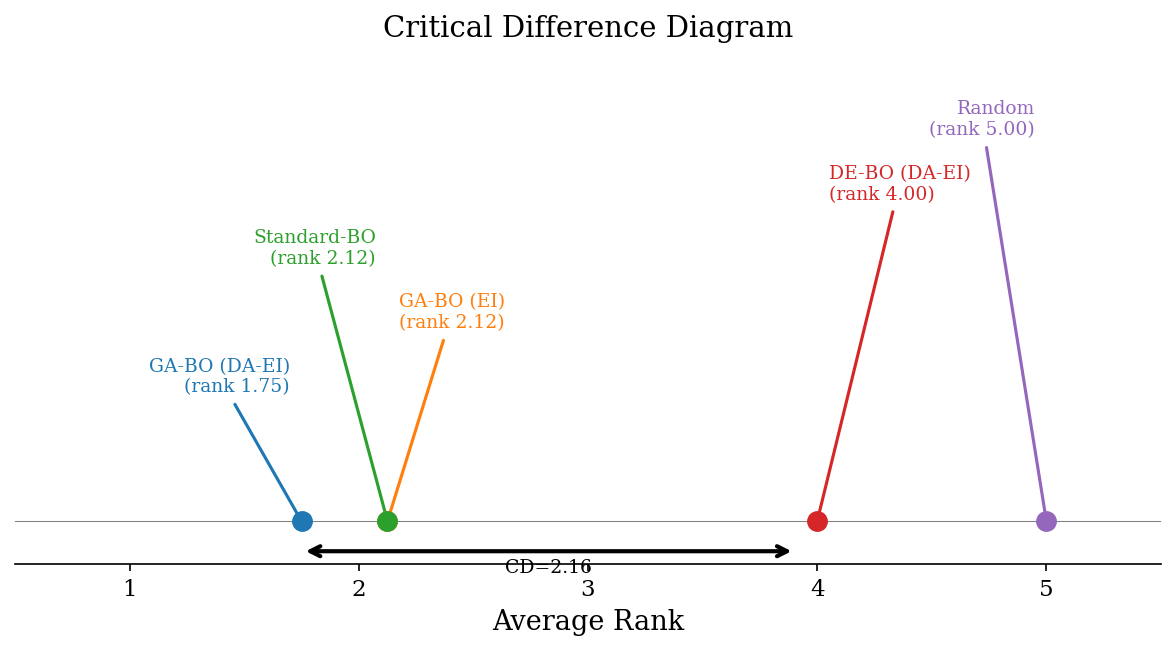


Nemenyi CD (α=0.05, k=5, N=8) = 2.1567
  GA-BO (DA-EI)              avg_rank = 1.750
  GA-BO (EI)                 avg_rank = 2.125
  Standard-BO                avg_rank = 2.125
  DE-BO (DA-EI)              avg_rank = 4.000
  Random                     avg_rank = 5.000


In [20]:
def critical_difference_diagram(
    results: Dict,
    functions: Dict[str, TestFunction],
    title: str = 'Critical Difference Diagram'
):
    """
    Compute average ranks across all benchmark functions and plot a
    Critical Difference (CD) diagram following Demšar (2006).
    """
    method_names = list(results.keys())
    fn_names     = list(functions.keys())

    # Build rank matrix: rows=functions, cols=methods
    rank_matrix = []
    for fname in fn_names:
        f_opt = functions[fname].global_optimum
        row   = []
        for mname in method_names:
            medians = np.median([r.best_values[-1] - f_opt
                                  for r in results[mname][fname]])
            row.append(medians)
        # Rank (ascending = better for regret)
        order = np.argsort(row)  # lower regret → rank 1
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(method_names)+1)
        rank_matrix.append(ranks)

    rank_matrix  = np.array(rank_matrix)          # (k_functions, n_methods)
    avg_ranks    = rank_matrix.mean(axis=0)        # (n_methods,)
    sorted_idx   = np.argsort(avg_ranks)           # best → worst
    sorted_names = [method_names[i] for i in sorted_idx]
    sorted_ranks = avg_ranks[sorted_idx]

    # Nemenyi CD (α=0.05)
    k = len(method_names)
    N = len(fn_names)
    # Critical values q_α for k=2..10 from Demšar Table 5 (α=0.05)
    q_alpha = {2:1.960, 3:2.344, 4:2.569, 5:2.728,
               6:2.850, 7:2.949, 8:3.031, 9:3.102, 10:3.164}
    q = q_alpha.get(k, 3.314)
    CD = q * np.sqrt(k*(k+1) / (6*N))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 2.5 + 0.4*k))
    ys = np.linspace(0.3, 0.9, k)
    colors = sns.color_palette('tab10', k)

    ax.axhline(y=0, color='gray', lw=0.5)
    ax.set_xlim(0.5, k+0.5)
    ax.set_ylim(-0.1, 1.1)

    for i, (name, rank, y, c) in enumerate(zip(sorted_names, sorted_ranks, ys, colors)):
        ax.plot([rank], [0], 'o', color=c, markersize=9, zorder=5)
        ha = 'right' if i % 2 == 0 else 'left'
        xoff = -0.05 if ha == 'right' else 0.05
        ax.annotate(f'{name}\n(rank {rank:.2f})',
                    xy=(rank, 0), xytext=(rank+xoff, y),
                    fontsize=9, ha=ha,
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.5),
                    color=c)

    # Draw CD bar at best rank
    best_rank = sorted_ranks[0]
    ax.annotate('', xy=(best_rank + CD, -0.07), xytext=(best_rank, -0.07),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(best_rank + CD/2, -0.12, f'CD={CD:.2f}',
            ha='center', fontsize=9)

    ax.set_xlabel('Average Rank')
    ax.set_title(title)
    ax.set_yticks([])
    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/cd_diagram.pdf', bbox_inches='tight')
    plt.show()
    print(f'\nNemenyi CD (α=0.05, k={k}, N={N}) = {CD:.4f}')
    for name, rank in zip(sorted_names, sorted_ranks):
        print(f'  {name:25s}  avg_rank = {rank:.3f}')


critical_difference_diagram(RESULTS, BENCHMARK_FUNCTIONS)

## 17. Computational Cost Analysis


=== Mean Wall-Time per Run (seconds) ===
Function       Ackley-10D  Ackley-5D  Branin  Hartmann-6D  Levy-6D  Rastrigin-10D  Rastrigin-5D  Rosenbrock-4D
Method                                                                                                        
DE-BO (DA-EI)        12.3       12.5    14.9         12.4     12.5           12.0          12.1           13.1
GA-BO (DA-EI)        11.1       10.0    12.0         10.8      9.8            9.8           9.2           10.0
GA-BO (EI)           11.2       10.5    12.3         12.1     10.9           11.5          11.2           10.9
Random                0.0        0.0     0.0          0.0      0.0            0.0           0.0            0.0
Standard-BO         131.3       42.8    13.8         54.6     67.6           25.1          23.3           47.1


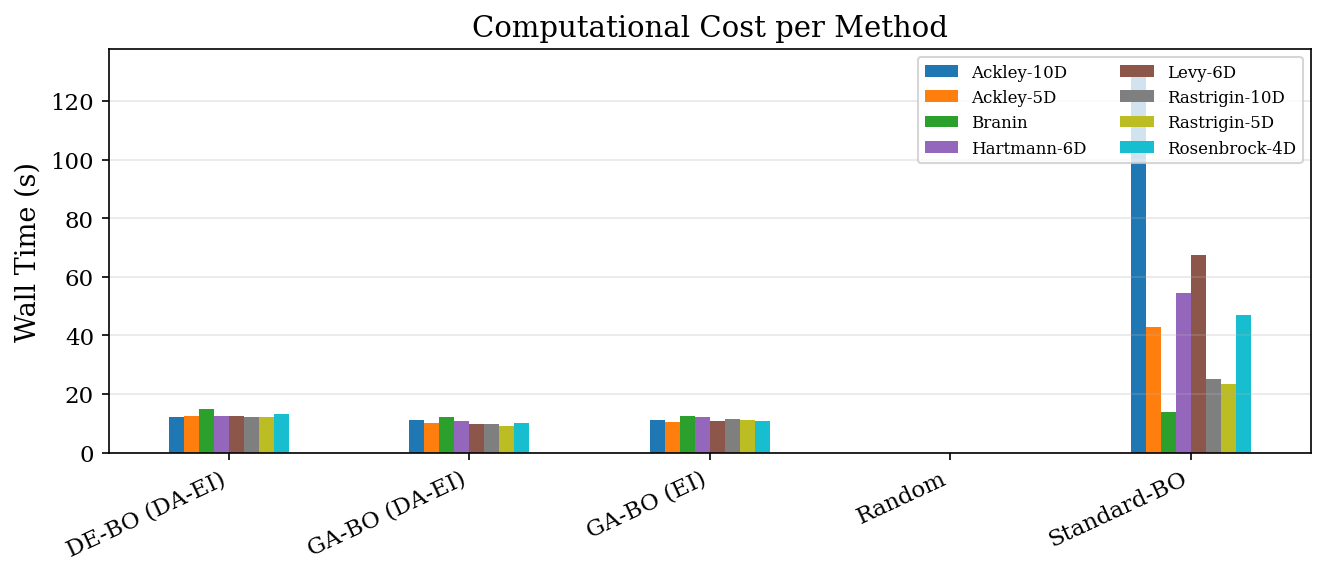

In [21]:
def compute_wall_times(
    results: Dict,
    functions: Dict[str, TestFunction]
) -> pd.DataFrame:
    rows = []
    for mname, fd in results.items():
        for fname, run_list in fd.items():
            times = [r.wall_time for r in run_list]
            rows.append(dict(
                Method=mname, Function=fname,
                Mean_Time_s=np.mean(times),
                Std_Time_s=np.std(times)
            ))
    return pd.DataFrame(rows)


time_df   = compute_wall_times(RESULTS, BENCHMARK_FUNCTIONS)
time_pivot= time_df.pivot(index='Method', columns='Function', values='Mean_Time_s')
print('\n=== Mean Wall-Time per Run (seconds) ===')
print(time_pivot.round(1).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
time_pivot.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_ylabel('Wall Time (s)')
ax.set_xlabel('')
ax.set_title('Computational Cost per Method')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/wall_time.pdf', bbox_inches='tight')
plt.show()

## 18. γ Sensitivity Analysis

γ_init:   0%|          | 0/6 [00:00<?, ?it/s]

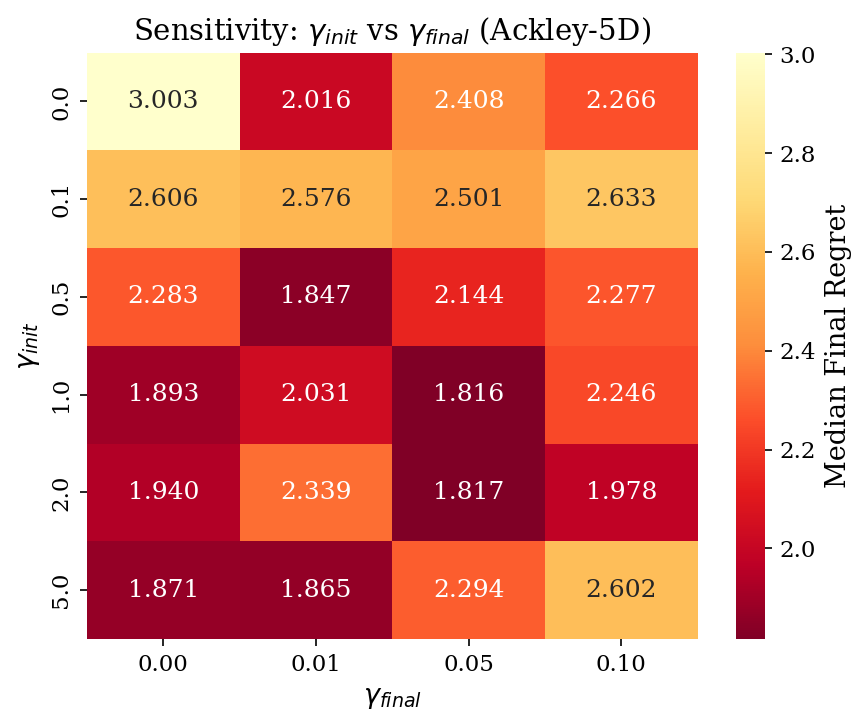

In [22]:
gamma_inits  = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
gamma_finals = [0.0, 0.01, 0.05, 0.1]
target_fn    = BENCHMARK_FUNCTIONS['Ackley-5D']

heat_data = np.zeros((len(gamma_inits), len(gamma_finals)))
for i, g_init in enumerate(tqdm(gamma_inits, desc='γ_init')):
    for j, g_final in enumerate(gamma_finals):
        regrets = []
        for seed in range(10):
            algo = GABO(
                bounds=target_fn.bounds, n_init=5, n_iter=30,
                acq_type='da_ei', gamma_init=g_init,
                gamma_final=g_final, gamma_decay='cosine', seed=seed
            )
            r = algo.run(target_fn.func)
            regrets.append(r.best_values[-1] - target_fn.global_optimum)
        heat_data[i, j] = np.median(regrets)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    heat_data, annot=True, fmt='.3f',
    xticklabels=[f'{g:.2f}' for g in gamma_finals],
    yticklabels=[f'{g:.1f}' for g in gamma_inits],
    cmap='YlOrRd_r', ax=ax,
    cbar_kws={'label': 'Median Final Regret'}
)
ax.set_xlabel(r'$\gamma_{final}$')
ax.set_ylabel(r'$\gamma_{init}$')
ax.set_title(r'Sensitivity: $\gamma_{init}$ vs $\gamma_{final}$ (Ackley-5D)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/gamma_sensitivity.pdf', bbox_inches='tight')
plt.show()

## 19. Final Summary & Export

In [23]:
# ── LaTeX table generator ──────────────────────────────────────────────────
def to_latex_table(
    pivot_mean: pd.DataFrame,
    pivot_std: pd.DataFrame,
    caption: str = 'Simple Regret (mean ± std)',
    label: str = 'tab:results'
) -> str:
    methods   = pivot_mean.index.tolist()
    fn_names  = pivot_mean.columns.tolist()

    # Mark best per column in bold
    best_per_fn = pivot_mean.idxmin(axis=0)

    cols  = 'l' + 'r'*len(fn_names)
    lines = []
    lines.append(r'\begin{table*}[t]')
    lines.append(r'\centering')
    lines.append(r'\caption{' + caption + r'}')
    lines.append(r'\label{' + label + r'}')
    lines.append(r'\resizebox{\textwidth}{!}{')
    lines.append(r'\begin{tabular}{' + cols + r'}')
    lines.append(r'\toprule')

    # Header
    header = 'Method & ' + ' & '.join(
        f'\\textbf{{{fn}}}' for fn in fn_names
    ) + r' \\'
    lines.append(header)
    lines.append(r'\midrule')

    for m in methods:
        cells = []
        for fn in fn_names:
            mu = pivot_mean.loc[m, fn]
            sd = pivot_std.loc[m, fn]
            cell = f'{mu:.4f} $\\pm$ {sd:.4f}'
            if best_per_fn[fn] == m:
                cell = r'\textbf{' + cell + r'}'
            cells.append(cell)
        lines.append(m + ' & ' + ' & '.join(cells) + r' \\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'}')
    lines.append(r'\end{table*}')
    return '\n'.join(lines)


latex_str = to_latex_table(pivot_mean, pivot_std)
print(latex_str[:2000], '\n...')
with open(f'{RESULTS_DIR}/results_table.tex', 'w', encoding='utf-8') as f:
    f.write(latex_str)
print('LaTeX table saved.')


# ── Summary print ──────────────────────────────────────────────────────────
print('\n' + '='*60)
print('EXPERIMENT SUMMARY')
print('='*60)
print(f'  Benchmark functions : {len(BENCHMARK_FUNCTIONS)}')
print(f'  Methods compared    : {len(METHODS)}')
print(f'  Seeds per setting   : {N_SEEDS}')
print(f'  Iterations per run  : {N_ITER}')
print(f'  Results dir         : {RESULTS_DIR}/')
print(f'  Figures dir         : {FIGURES_DIR}/')
print('='*60)
print('\nAll experiments complete. Ready for paper writing.')

\begin{table*}[t]
\centering
\caption{Simple Regret (mean ± std)}
\label{tab:results}
\resizebox{\textwidth}{!}{
\begin{tabular}{lrrrrrrrr}
\toprule
Method & \textbf{Ackley-10D} & \textbf{Ackley-5D} & \textbf{Branin} & \textbf{Hartmann-6D} & \textbf{Levy-6D} & \textbf{Rastrigin-10D} & \textbf{Rastrigin-5D} & \textbf{Rosenbrock-4D} \\
\midrule
DE-BO (DA-EI) & 6.7543 $\pm$ 0.6097 & 5.0144 $\pm$ 0.6232 & 0.0669 $\pm$ 0.1288 & 1.1221 $\pm$ 0.7825 & 4.2190 $\pm$ 1.6255 & 106.7983 $\pm$ 12.0900 & 33.1942 $\pm$ 9.4003 & 9.9776 $\pm$ 4.5572 \\
GA-BO (DA-EI) & \textbf{2.5634 $\pm$ 0.4084} & \textbf{1.4200 $\pm$ 0.6335} & 0.0027 $\pm$ 0.0028 & 0.1584 $\pm$ 0.1081 & \textbf{0.9781 $\pm$ 0.5000} & \textbf{84.0529 $\pm$ 21.0540} & 23.3478 $\pm$ 12.9871 & 3.5188 $\pm$ 1.6532 \\
GA-BO (EI) & 2.9209 $\pm$ 0.6859 & 1.9633 $\pm$ 0.9319 & \textbf{0.0014 $\pm$ 0.0011} & \textbf{0.1191 $\pm$ 0.1191} & 5.4206 $\pm$ 5.3864 & 84.3424 $\pm$ 19.0298 & 24.3882 $\pm$ 9.7628 & 3.9422 $\pm$ 1.7337 \\
Random & 7.764